# Complete Historical PM2.5 Data and Trend Attributes

This notebook completes the feature engineering task for the group PM2.5 forecasting project.

It includes:

1. Historical PM2.5 data features.
2. Extracted trend attributes.
3. Seasonal components.
4. Spatiotemporal peer-station feature section with DTW logic.
5. Correct save path inside `data/features/`.

## Important dataset note

The current uploaded dataset is a **single-station daily dataset** for London Marylebone Road. Therefore, true spatiotemporal peer-station features cannot be calculated from this dataset alone.

The notebook still includes the peer-station DTW section, but it only activates when the input dataset contains at least two stations.


## Purpose of Historical PM2.5 data features.
This notebook performs feature engineering for PM2.5 air-quality forecasting. The aim is to transform raw daily PM2.5 observations into useful time-series features that can support machine learning forecasting models.

The engineered features include historical lag values, rolling trend attributes, rate-of-change measures, seasonal cyclical features, and a DTW-based peer-station feature section for future multi-station data.

## 0. Imports

In [1]:
from pathlib import Path
import csv
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Imports loaded successfully.")

Imports loaded successfully.


## 1.Load uploaded UK-Air PM2.5 dataset

In [4]:
# =====================================
# Load uploaded UK-Air PM2.5 dataset 
# =====================================

current_dir = Path.cwd()

# Works when notebook is in AIR/notebooks/
if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent

# Works when notebook is opened from AIR/
elif (current_dir / "data").exists():
    PROJECT_ROOT = current_dir

# Fallback for local machine
else:
    PROJECT_ROOT = Path.home() / "AIR"

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
FEATURE_OUTPUT_DIR = PROJECT_ROOT / "data" / "features"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Current notebook folder:", current_dir)
print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Feature output folder:", FEATURE_OUTPUT_DIR)
print("Figure output folder:", FIGURE_DIR)

Current notebook folder: /Users/hirunikeshika/AIR/notebooks
Project root: /Users/hirunikeshika/AIR
Raw data folder: /Users/hirunikeshika/AIR/data/raw
Feature output folder: /Users/hirunikeshika/AIR/data/features
Figure output folder: /Users/hirunikeshika/AIR/outputs/figures


## 2. Load PM2.5 dataset


In [7]:
# =========================================================
# Load PM2.5 dataset 
# =========================================================

DATA_FILE = RAW_DATA_DIR / "PM2.5_AirQualityData_2021-2025.csv"

print("Looking for file:")
print(DATA_FILE)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"File not found: {DATA_FILE}\n"
        "Please place the CSV file inside data/raw/ in the GitHub project."
    )


def read_station_name(filepath):
    """Read station name from UK-Air metadata rows."""

    try:
        with open(filepath, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
            rows = list(csv.reader(f))

        station_name = rows[3][1].strip()

        if station_name.lower() in ["nan", "", "none"]:
            station_name = "London Marylebone Road"

    except Exception:
        station_name = "London Marylebone Road"

    return station_name


def load_defra_single_station(filepath):
    """
    Load a DEFRA/UK-Air single-station daily PM2.5 CSV file.

    The uploaded UK-Air file contains metadata rows followed by a data header:
    Date, PM2.5 particulate matter (Daily measured), Status
    """

    station_name = read_station_name(filepath)

    # Read actual data after metadata rows
    raw = pd.read_csv(filepath, skiprows=10, header=0)

    raw = raw.rename(columns={
        raw.columns[0]: "date",
        raw.columns[1]: "pm25_raw"
    })

    if raw.shape[1] >= 3:
        raw = raw.rename(columns={raw.columns[2]: "status_raw"})
    else:
        raw["status_raw"] = np.nan

    raw["date_raw"] = raw["date"].astype(str)

    # Correct for ISO date format such as 2021-01-01
    raw["date"] = pd.to_datetime(
        raw["date_raw"],
        format="%Y-%m-%d",
        errors="coerce"
    )

    # Fallback for any non-ISO date rows
    missing_dates = raw["date"].isna()

    if missing_dates.any():
        raw.loc[missing_dates, "date"] = pd.to_datetime(
            raw.loc[missing_dates, "date_raw"],
            errors="coerce",
            dayfirst=True
        )

    raw["pm25_raw"] = pd.to_numeric(raw["pm25_raw"], errors="coerce")

    raw = raw.dropna(subset=["date"]).copy()
    raw["date"] = raw["date"].dt.normalize()

    raw["station"] = station_name
    raw["source_file"] = Path(filepath).name

    raw = raw[[
        "date",
        "date_raw",
        "station",
        "pm25_raw",
        "status_raw",
        "source_file"
    ]]

    raw = (
        raw
        .sort_values(["station", "date"])
        .drop_duplicates(subset=["station", "date"])
        .reset_index(drop=True)
    )

    return raw


df = load_defra_single_station(DATA_FILE)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)
print("Station:", df["station"].iloc[0])
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Missing PM2.5 count:", df["pm25_raw"].isna().sum())
print("Missing PM2.5 percentage:", round(df["pm25_raw"].isna().mean() * 100, 2), "%")

df.head(10)

Looking for file:
/Users/hirunikeshika/AIR/data/raw/PM2.5_AirQualityData_2021-2025.csv

Dataset loaded successfully.
Shape: (1825, 6)
Station: London Marylebone Road
Date range: 2021-01-01 00:00:00 to 2025-12-30 00:00:00
Missing PM2.5 count: 86
Missing PM2.5 percentage: 4.71 %


,date,date_raw,station,pm25_raw,status_raw,source_file
0,2021-01-01,2021-01-01,London Marylebone Road,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv
1,2021-01-02,2021-01-02,London Marylebone Road,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv
2,2021-01-03,2021-01-03,London Marylebone Road,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv
3,2021-01-04,2021-01-04,London Marylebone Road,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv
4,2021-01-05,2021-01-05,London Marylebone Road,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv
5,2021-01-06,2021-01-06,London Marylebone Road,4.542,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv
6,2021-01-07,2021-01-07,London Marylebone Road,15.333,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv
7,2021-01-08,2021-01-08,London Marylebone Road,19.958,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv
8,2021-01-09,2021-01-09,London Marylebone Road,15.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv
9,2021-01-10,2021-01-10,London Marylebone Road,16.583,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv


## 3. Complete daily date index

This step ensures the dataset has one row per calendar day. If any dates are missing from the file, they are added as missing PM2.5 rows.


In [10]:
# =========================================================
# Complete daily date index
# =========================================================

full_station_frames = []

for station, station_df in df.groupby("station"):

    full_dates = pd.date_range(
        station_df["date"].min(),
        station_df["date"].max(),
        freq="D"
    )

    full_station = pd.DataFrame({
        "date": full_dates,
        "station": station
    })

    full_station = full_station.merge(
        station_df,
        on=["date", "station"],
        how="left"
    )

    full_station_frames.append(full_station)

df = pd.concat(full_station_frames, ignore_index=True)

df["source_file"] = df["source_file"].fillna(DATA_FILE.name)
df["date_raw"] = df["date_raw"].fillna(df["date"].dt.strftime("%Y-%m-%d"))
df["status_raw"] = df["status_raw"].fillna("Missing calendar day")

df["pm25_missing_flag"] = df["pm25_raw"].isna().astype(int)

print("Completed daily date index.")
print("Shape after daily completion:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Missing PM2.5 count:", df["pm25_raw"].isna().sum())

df.head()

Completed daily date index.
Shape after daily completion: (1825, 7)
Date range: 2021-01-01 00:00:00 to 2025-12-30 00:00:00
Missing PM2.5 count: 86


,date,station,date_raw,pm25_raw,status_raw,source_file,pm25_missing_flag
0,2021-01-01,London Marylebone Road,2021-01-01,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0
1,2021-01-02,London Marylebone Road,2021-01-02,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0
2,2021-01-03,London Marylebone Road,2021-01-03,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0
3,2021-01-04,London Marylebone Road,2021-01-04,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0
4,2021-01-05,London Marylebone Road,2021-01-05,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0


## 4. Timestamp and seasonal base features

In [13]:
# =========================================================
# Timestamp and seasonal base features
# =========================================================

df = df.sort_values(["station", "date"]).reset_index(drop=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_year"] = df["date"].dt.dayofyear
df["day_of_week"] = df["date"].dt.day_name()
df["quarter"] = df["date"].dt.quarter

print("Timestamp features created.")

df.head()

Timestamp features created.


,date,station,date_raw,pm25_raw,status_raw,source_file,pm25_missing_flag,year,month,day,day_of_year,day_of_week,quarter
0,2021-01-01,London Marylebone Road,2021-01-01,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,1,1,Friday,1
1,2021-01-02,London Marylebone Road,2021-01-02,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,2,2,Saturday,1
2,2021-01-03,London Marylebone Road,2021-01-03,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,3,3,Sunday,1
3,2021-01-04,London Marylebone Road,2021-01-04,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,4,4,Monday,1
4,2021-01-05,London Marylebone Road,2021-01-05,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,5,5,Tuesday,1


In [15]:
# =========================================================
# PM2.5 column for feature engineering
# =========================================================

df["pm25_for_features"] = (
    df.groupby("station")["pm25_raw"]
    .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
)

PM25_FEATURE_COL = "pm25_for_features"

print("Feature source column:", PM25_FEATURE_COL)
print("Missing values in raw PM2.5:", df["pm25_raw"].isna().sum())
print("Missing values in feature PM2.5:", df[PM25_FEATURE_COL].isna().sum())

df[["date", "station", "pm25_raw", "pm25_for_features", "pm25_missing_flag"]].head(15)

Feature source column: pm25_for_features
Missing values in raw PM2.5: 86
Missing values in feature PM2.5: 0


,date,station,pm25_raw,pm25_for_features,pm25_missing_flag
0,2021-01-01,London Marylebone Road,17.167,17.167,0
1,2021-01-02,London Marylebone Road,5.167,5.167,0
2,2021-01-03,London Marylebone Road,4.500,4.500,0
3,2021-01-04,London Marylebone Road,3.458,3.458,0
4,2021-01-05,London Marylebone Road,3.250,3.250,0
5,2021-01-06,London Marylebone Road,4.542,4.542,0
6,2021-01-07,London Marylebone Road,15.333,15.333,0
7,2021-01-08,London Marylebone Road,19.958,19.958,0
8,2021-01-09,London Marylebone Road,15.458,15.458,0
9,2021-01-10,London Marylebone Road,16.583,16.583,0


## 5. PM2.5 column for feature engineering

Raw PM2.5 is preserved in `pm25_raw`.

For feature engineering, a time-aware interpolated column is created as `pm25_for_features`. This avoids gaps breaking lag and rolling features while keeping an audit flag in `pm25_missing_flag`.


## 6. Historical PM2.5 data features

Previous PM2.5 observations are important because air-pollution levels often depend on recent pollution behaviour. Since this dataset is daily rather than hourly, lag features are created using previous daily PM2.5 values instead of previous hourly readings.

All lag features are shifted so that only past observations are used. This prevents data leakage from the prediction day.

The literature often uses previous hourly PM2.5 sequences, such as 12 to 72 hours. This dataset is daily, so the equivalent feature strategy uses previous daily observations.

Created lag features:

- 1 day
- 2 days
- 3 days
- 6 days
- 7 days
- 12 days
- 14 days
- 30 days


In [20]:
# =========================================================
# Historical PM2.5 lag features
# =========================================================

lag_days = [1, 2, 3, 6, 7, 12, 14, 30]

for lag in lag_days:
    df[f"pm25_lag_{lag}d"] = (
        df.groupby("station")[PM25_FEATURE_COL]
        .shift(lag)
    )

lag_feature_cols = [f"pm25_lag_{lag}d" for lag in lag_days]

print("Historical PM2.5 lag features created:")
print(lag_feature_cols)

df[["date", "station", "pm25_raw", PM25_FEATURE_COL] + lag_feature_cols].head(15)

Historical PM2.5 lag features created:
['pm25_lag_1d', 'pm25_lag_2d', 'pm25_lag_3d', 'pm25_lag_6d', 'pm25_lag_7d', 'pm25_lag_12d', 'pm25_lag_14d', 'pm25_lag_30d']


,date,station,pm25_raw,pm25_for_features,pm25_lag_1d,pm25_lag_2d,pm25_lag_3d,pm25_lag_6d,pm25_lag_7d,pm25_lag_12d,pm25_lag_14d,pm25_lag_30d
0,2021-01-01,London Marylebone Road,17.167,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,5.167,5.167,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,London Marylebone Road,4.500,4.500,5.167,17.167,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,London Marylebone Road,3.458,3.458,4.500,5.167,17.167,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,London Marylebone Road,3.250,3.250,3.458,4.500,5.167,NaN,NaN,NaN,NaN,NaN
5,2021-01-06,London Marylebone Road,4.542,4.542,3.250,3.458,4.500,NaN,NaN,NaN,NaN,NaN
6,2021-01-07,London Marylebone Road,15.333,15.333,4.542,3.250,3.458,17.167,NaN,NaN,NaN,NaN
7,2021-01-08,London Marylebone Road,19.958,19.958,15.333,4.542,3.250,5.167,17.167,NaN,NaN,NaN
8,2021-01-09,London Marylebone Road,15.458,15.458,19.958,15.333,4.542,4.500,5.167,NaN,NaN,NaN
9,2021-01-10,London Marylebone Road,16.583,16.583,15.458,19.958,15.333,3.458,4.500,NaN,NaN,NaN


## 7. Extracted trend attributes

This section creates more than 15 trend attributes using only previous PM2.5 values.

Included attributes:

- rolling averages
- rolling standard deviations
- rolling minimum values
- rolling maximum values
- rolling ranges
- differences between previous time steps
- rates of change


In [23]:
# =========================================================
# Rolling trend attributes
# =========================================================

shifted_pm25 = df.groupby("station")[PM25_FEATURE_COL].shift(1)

rolling_windows = [3, 6, 7, 12, 14, 30]

for window in rolling_windows:

    df[f"pm25_roll_mean_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_std_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=2)
        .std()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_min_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=1)
        .min()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_max_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=1)
        .max()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_range_{window}d"] = (
        df[f"pm25_roll_max_{window}d"] - df[f"pm25_roll_min_{window}d"]
    )

rolling_feature_cols = [
    col for col in df.columns
    if col.startswith("pm25_roll_")
]

print("Rolling trend features created:", len(rolling_feature_cols))
print(rolling_feature_cols)

df[["date", "station", PM25_FEATURE_COL] + rolling_feature_cols].head(15)

Rolling trend features created: 30
['pm25_roll_mean_3d', 'pm25_roll_std_3d', 'pm25_roll_min_3d', 'pm25_roll_max_3d', 'pm25_roll_range_3d', 'pm25_roll_mean_6d', 'pm25_roll_std_6d', 'pm25_roll_min_6d', 'pm25_roll_max_6d', 'pm25_roll_range_6d', 'pm25_roll_mean_7d', 'pm25_roll_std_7d', 'pm25_roll_min_7d', 'pm25_roll_max_7d', 'pm25_roll_range_7d', 'pm25_roll_mean_12d', 'pm25_roll_std_12d', 'pm25_roll_min_12d', 'pm25_roll_max_12d', 'pm25_roll_range_12d', 'pm25_roll_mean_14d', 'pm25_roll_std_14d', 'pm25_roll_min_14d', 'pm25_roll_max_14d', 'pm25_roll_range_14d', 'pm25_roll_mean_30d', 'pm25_roll_std_30d', 'pm25_roll_min_30d', 'pm25_roll_max_30d', 'pm25_roll_range_30d']


,date,station,pm25_for_features,pm25_roll_mean_3d,pm25_roll_std_3d,pm25_roll_min_3d,pm25_roll_max_3d,pm25_roll_range_3d,pm25_roll_mean_6d,pm25_roll_std_6d,...,pm25_roll_mean_14d,pm25_roll_std_14d,pm25_roll_min_14d,pm25_roll_max_14d,pm25_roll_range_14d,pm25_roll_mean_30d,pm25_roll_std_30d,pm25_roll_min_30d,pm25_roll_max_30d,pm25_roll_range_30d
0,2021-01-01,London Marylebone Road,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,5.167,17.167000,NaN,17.167,17.167,0.000,17.167000,NaN,...,17.167000,NaN,17.167,17.167,0.000,17.167000,NaN,17.167,17.167,0.000
2,2021-01-03,London Marylebone Road,4.500,11.167000,8.485281,5.167,17.167,12.000,11.167000,8.485281,...,11.167000,8.485281,5.167,17.167,12.000,11.167000,8.485281,5.167,17.167,12.000
3,2021-01-04,London Marylebone Road,3.458,8.944667,7.128555,4.500,17.167,12.667,8.944667,7.128555,...,8.944667,7.128555,4.500,17.167,12.667,8.944667,7.128555,4.500,17.167,12.667
4,2021-01-05,London Marylebone Road,3.250,4.375000,0.861330,3.458,5.167,1.709,7.573000,6.434548,...,7.573000,6.434548,3.458,17.167,13.709,7.573000,6.434548,3.458,17.167,13.709
5,2021-01-06,London Marylebone Road,4.542,3.736000,0.669767,3.250,4.500,1.250,6.708400,5.898324,...,6.708400,5.898324,3.250,17.167,13.917,6.708400,5.898324,3.250,17.167,13.917
6,2021-01-07,London Marylebone Road,15.333,3.750000,0.693732,3.250,4.542,1.292,6.347333,5.349242,...,6.347333,5.349242,3.250,17.167,13.917,6.347333,5.349242,3.250,17.167,13.917
7,2021-01-08,London Marylebone Road,19.958,7.708333,6.634680,3.250,15.333,12.083,6.041667,4.608436,...,7.631000,5.948103,3.250,17.167,13.917,7.631000,5.948103,3.250,17.167,13.917
8,2021-01-09,London Marylebone Road,15.458,13.277667,7.910851,4.542,19.958,15.416,8.506833,7.247419,...,9.171875,7.022821,3.250,19.958,16.708,9.171875,7.022821,3.250,19.958,16.708
9,2021-01-10,London Marylebone Road,16.583,16.916333,2.634902,15.333,19.958,4.625,10.333167,7.414532,...,9.870333,6.895333,3.250,19.958,16.708,9.870333,6.895333,3.250,19.958,16.708


In [25]:
# =========================================================
# Difference and rate-of-change trend features
# =========================================================

difference_gaps = [1, 3, 6, 7, 12, 14]

for gap in difference_gaps:

    if f"pm25_lag_{gap}d" in df.columns:
        df[f"pm25_diff_{gap}d"] = (
            df["pm25_lag_1d"] - df[f"pm25_lag_{gap}d"]
        )

        df[f"pm25_rate_change_{gap}d"] = (
            df[f"pm25_diff_{gap}d"] / (df[f"pm25_lag_{gap}d"] + 1e-6)
        )

trend_change_cols = [
    col for col in df.columns
    if col.startswith("pm25_diff_")
    or col.startswith("pm25_rate_change_")
]

print("Difference and rate-of-change features created:", len(trend_change_cols))
print(trend_change_cols)

df[["date", "station", PM25_FEATURE_COL] + trend_change_cols].head(15)

Difference and rate-of-change features created: 12
['pm25_diff_1d', 'pm25_rate_change_1d', 'pm25_diff_3d', 'pm25_rate_change_3d', 'pm25_diff_6d', 'pm25_rate_change_6d', 'pm25_diff_7d', 'pm25_rate_change_7d', 'pm25_diff_12d', 'pm25_rate_change_12d', 'pm25_diff_14d', 'pm25_rate_change_14d']


,date,station,pm25_for_features,pm25_diff_1d,pm25_rate_change_1d,pm25_diff_3d,pm25_rate_change_3d,pm25_diff_6d,pm25_rate_change_6d,pm25_diff_7d,pm25_rate_change_7d,pm25_diff_12d,pm25_rate_change_12d,pm25_diff_14d,pm25_rate_change_14d
0,2021-01-01,London Marylebone Road,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,5.167,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,London Marylebone Road,4.500,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,London Marylebone Road,3.458,0.0,0.0,-12.667,-0.737869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,London Marylebone Road,3.250,0.0,0.0,-1.709,-0.330753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021-01-06,London Marylebone Road,4.542,0.0,0.0,-1.250,-0.277778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021-01-07,London Marylebone Road,15.333,0.0,0.0,1.084,0.313476,-12.625,-0.735423,NaN,NaN,NaN,NaN,NaN,NaN
7,2021-01-08,London Marylebone Road,19.958,0.0,0.0,12.083,3.717845,10.166,1.967486,-1.834,-0.106833,NaN,NaN,NaN,NaN
8,2021-01-09,London Marylebone Road,15.458,0.0,0.0,15.416,3.394099,15.458,3.435110,14.791,2.862589,NaN,NaN,NaN,NaN
9,2021-01-10,London Marylebone Road,16.583,0.0,0.0,0.125,0.008152,12.000,3.470213,10.958,2.435111,NaN,NaN,NaN,NaN


## 8. Seasonal cyclical components

In [28]:
# =========================================================
# Seasonal cyclical components
# =========================================================

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["day_of_year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["day_of_year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

seasonal_feature_cols = [
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

print("Seasonal cyclical features created:")
print(seasonal_feature_cols)

df[["date", "station", "month", "day_of_year"] + seasonal_feature_cols].head(10)

Seasonal cyclical features created:
['month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos']


,date,station,month,day_of_year,month_sin,month_cos,day_of_year_sin,day_of_year_cos
0,2021-01-01,London Marylebone Road,1,1,0.5,0.866025,0.017202,0.999852
1,2021-01-02,London Marylebone Road,1,2,0.5,0.866025,0.034398,0.999408
2,2021-01-03,London Marylebone Road,1,3,0.5,0.866025,0.051584,0.998669
3,2021-01-04,London Marylebone Road,1,4,0.5,0.866025,0.068755,0.997634
4,2021-01-05,London Marylebone Road,1,5,0.5,0.866025,0.085906,0.996303
5,2021-01-06,London Marylebone Road,1,6,0.5,0.866025,0.103031,0.994678
6,2021-01-07,London Marylebone Road,1,7,0.5,0.866025,0.120126,0.992759
7,2021-01-08,London Marylebone Road,1,8,0.5,0.866025,0.137185,0.990545
8,2021-01-09,London Marylebone Road,1,9,0.5,0.866025,0.154204,0.988039
9,2021-01-10,London Marylebone Road,1,10,0.5,0.866025,0.171177,0.985240


## 9. Spatiotemporal peer station features using DTW

Spatiotemporal peer-station features are designed to capture pollution behaviour from similar monitoring stations. Dynamic Time Warping (DTW) is used to compare temporal PM2.5 patterns between stations and select peer stations based on similarity rather than only geographical distance.

The current uploaded dataset contains only one station, London Marylebone Road. Therefore, peer-station features cannot be calculated from this dataset alone. This section is included so the notebook can support peer-station feature creation when a multi-station dataset is added.

Peer-station features require at least two monitoring stations.

If the dataset contains multiple stations, this section selects peer stations using Dynamic Time Warping (DTW), then creates lagged and rolling peer PM2.5 features.

For the current single-station London Marylebone Road dataset, this section will report that peer features are not available.


In [31]:
# =========================================================
# Spatiotemporal peer station feature section
# =========================================================

def zscore_array(values):
    values = np.asarray(values, dtype=float)
    return (values - np.nanmean(values)) / (np.nanstd(values) + 1e-6)


def prepare_series_for_similarity(series):
    return (
        series
        .interpolate(limit_direction="both")
        .ffill()
        .bfill()
    )


def dtw_distance_windowed(series_a, series_b, window=8):
    valid_mask = series_a.notna() & series_b.notna()

    a = series_a[valid_mask].values
    b = series_b[valid_mask].values

    if len(a) < 10 or len(b) < 10:
        return np.inf

    a = zscore_array(a)
    b = zscore_array(b)

    n = len(a)
    m = len(b)

    window = max(window, abs(n - m))

    previous = np.full(m + 1, np.inf)
    previous[0] = 0

    for i in range(1, n + 1):
        current = np.full(m + 1, np.inf)

        j_start = max(1, i - window)
        j_end = min(m, i + window)

        for j in range(j_start, j_end + 1):
            cost = abs(a[i - 1] - b[j - 1])
            current[j] = cost + min(
                previous[j],
                current[j - 1],
                previous[j - 1]
            )

        previous = current

    return previous[m] / (n + m)


station_count = df["station"].nunique()

print("Number of stations:", station_count)

peer_station_df = pd.DataFrame()
peer_features_df = pd.DataFrame()

if station_count < 2:

    print(
        "Peer-station DTW features are not available because this dataset "
        "contains only one monitoring station."
    )

    df["peer_feature_available"] = False
    df["peer_feature_note"] = "Not available: single-station dataset."

else:

    pm25_wide = df.pivot_table(
        index="date",
        columns="station",
        values=PM25_FEATURE_COL,
        aggfunc="mean"
    ).sort_index()

    stations = pm25_wide.columns.tolist()

    pm25_similarity = (
        pm25_wide
        .apply(prepare_series_for_similarity)
        .resample("7D")
        .mean()
    )

    peer_records = []

    for station in stations:

        distances = []

        for peer_station in stations:

            if station == peer_station:
                continue

            distance = dtw_distance_windowed(
                pm25_similarity[station],
                pm25_similarity[peer_station],
                window=8
            )

            distances.append({
                "station": station,
                "peer_station": peer_station,
                "dtw_distance": distance
            })

        station_peer_df = (
            pd.DataFrame(distances)
            .sort_values("dtw_distance")
            .reset_index(drop=True)
        )

        number_of_peers = min(3, len(station_peer_df))

        top_peers = station_peer_df.head(number_of_peers).copy()
        top_peers["peer_rank"] = range(1, number_of_peers + 1)

        peer_records.append(top_peers)

    peer_station_df = pd.concat(peer_records, ignore_index=True)

    peer_feature_rows = []

    for station in stations:

        selected_peer_info = peer_station_df[
            peer_station_df["station"] == station
        ].copy()

        selected_peers = selected_peer_info["peer_station"].tolist()

        peer_values = pm25_wide[selected_peers]

        distances = selected_peer_info["dtw_distance"].values
        weights = 1 / (distances + 1e-6)
        weights = weights / weights.sum()

        weighted_peer_lag_1d = (
            peer_values.shift(1)
            .multiply(weights, axis=1)
            .sum(axis=1)
        )

        peer_features = pd.DataFrame({
            "date": pm25_wide.index,
            "station": station,
            "peer_pm25_mean_lag_1d": peer_values.shift(1).mean(axis=1),
            "peer_pm25_median_lag_1d": peer_values.shift(1).median(axis=1),
            "peer_pm25_max_lag_1d": peer_values.shift(1).max(axis=1),
            "peer_pm25_min_lag_1d": peer_values.shift(1).min(axis=1),
            "peer_pm25_weighted_lag_1d": weighted_peer_lag_1d,
            "peer_pm25_mean_lag_3d": peer_values.shift(3).mean(axis=1),
            "peer_pm25_mean_lag_7d": peer_values.shift(7).mean(axis=1),
            "peer_pm25_roll_mean_7d": (
                peer_values
                .shift(1)
                .rolling(window=7, min_periods=1)
                .mean()
                .mean(axis=1)
            ),
            "peer_station_count": len(selected_peers)
        })

        peer_feature_rows.append(peer_features)

    peer_features_df = pd.concat(peer_feature_rows, ignore_index=True)

    df = df.merge(
        peer_features_df,
        on=["date", "station"],
        how="left"
    )

    df["peer_feature_available"] = True
    df["peer_feature_note"] = "Available: multi-station DTW peer features created."

    print("DTW peer features created successfully.")

peer_station_df.head()

Number of stations: 1
Peer-station DTW features are not available because this dataset contains only one monitoring station.


""


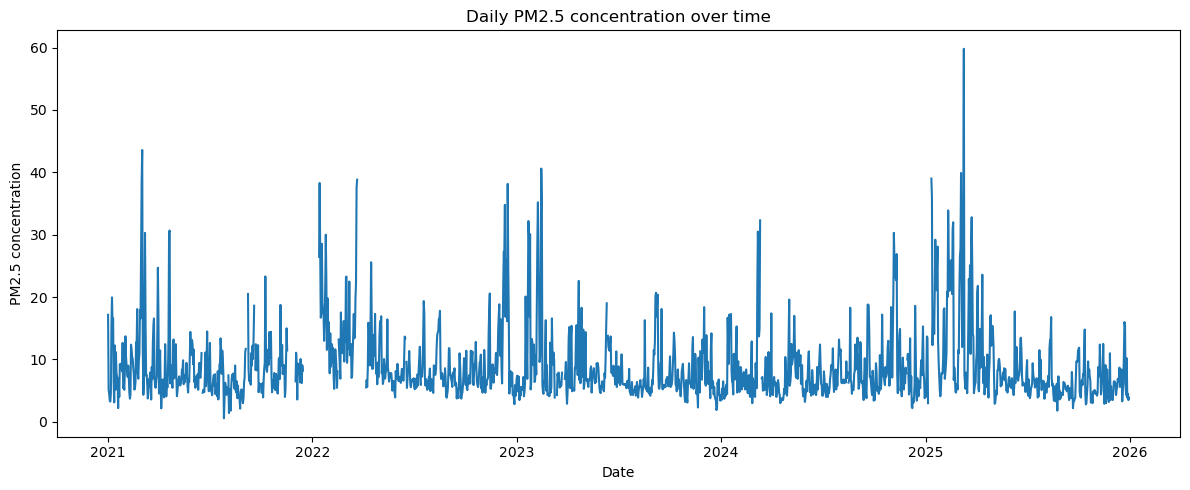

Saved: /Users/hirunikeshika/AIR/outputs/figures/daily_pm25_time_series.png


In [33]:
# =========================================================
# Graphs for feature engineering evidence
# =========================================================

import matplotlib.pyplot as plt

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Use PM2.5 column for plotting
plot_col = "pm25_raw"

# 1. Raw PM2.5 time-series graph
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df[plot_col])
plt.title("Daily PM2.5 concentration over time")
plt.xlabel("Date")
plt.ylabel("PM2.5 concentration")
plt.tight_layout()

time_series_path = FIGURE_DIR / "daily_pm25_time_series.png"
plt.savefig(time_series_path, dpi=300)
plt.show()

print("Saved:", time_series_path)

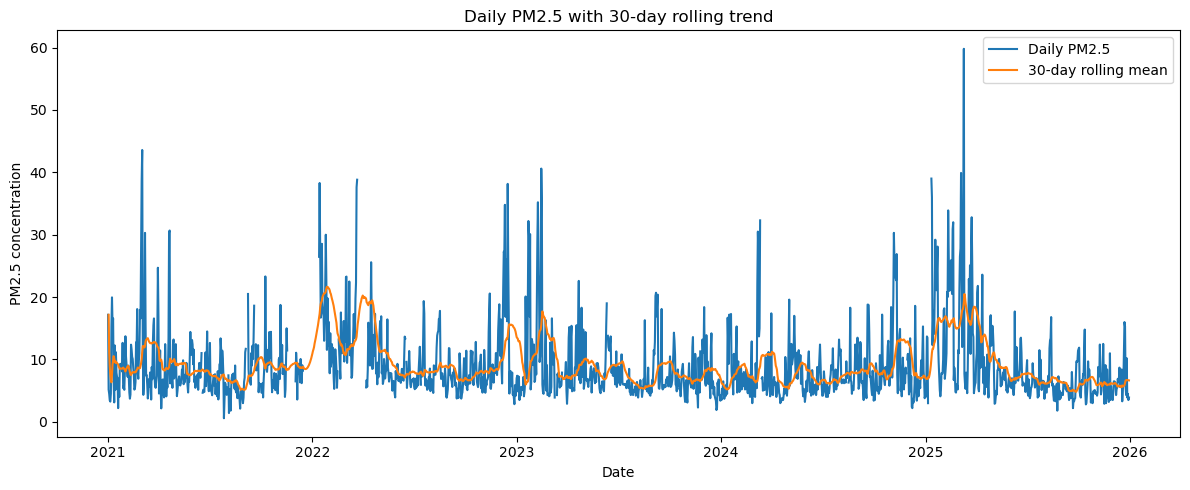

Saved: /Users/hirunikeshika/AIR/outputs/figures/pm25_30_day_rolling_trend.png


In [36]:
# =========================================================
# 2. PM2.5 with rolling mean trend
# =========================================================

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["pm25_raw"], label="Daily PM2.5")
plt.plot(df["date"], df["pm25_roll_mean_30d"], label="30-day rolling mean")
plt.title("Daily PM2.5 with 30-day rolling trend")
plt.xlabel("Date")
plt.ylabel("PM2.5 concentration")
plt.legend()
plt.tight_layout()

rolling_trend_path = FIGURE_DIR / "pm25_30_day_rolling_trend.png"
plt.savefig(rolling_trend_path, dpi=300)
plt.show()

print("Saved:", rolling_trend_path)

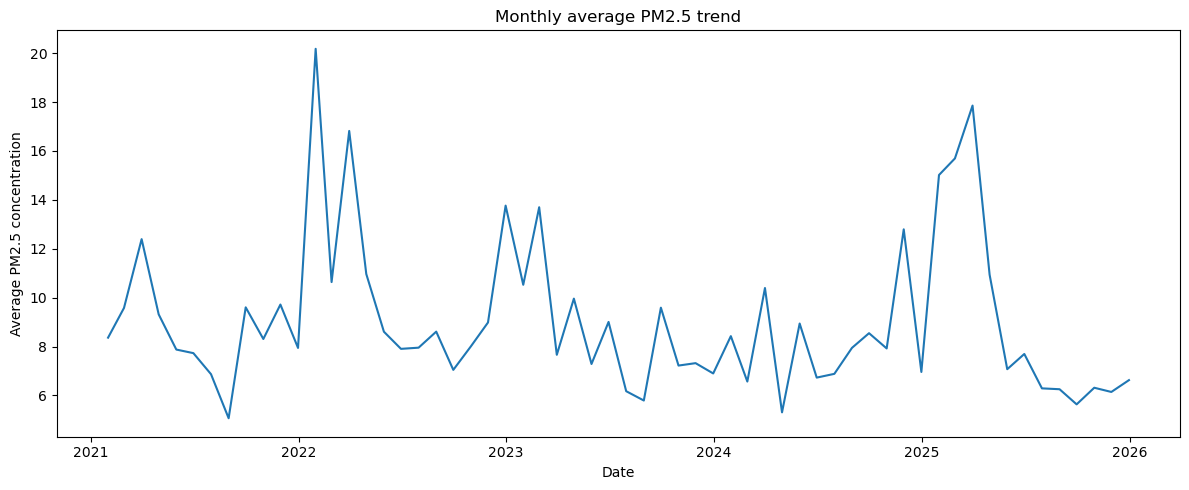

Saved: /Users/hirunikeshika/AIR/outputs/figures/monthly_average_pm25_trend.png


In [38]:
# =========================================================
# 3. Monthly average PM2.5 trend
# =========================================================

monthly_pm25 = (
    df.set_index("date")["pm25_raw"]
    .resample("M")
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_pm25["date"], monthly_pm25["pm25_raw"])
plt.title("Monthly average PM2.5 trend")
plt.xlabel("Date")
plt.ylabel("Average PM2.5 concentration")
plt.tight_layout()

monthly_trend_path = FIGURE_DIR / "monthly_average_pm25_trend.png"
plt.savefig(monthly_trend_path, dpi=300)
plt.show()

print("Saved:", monthly_trend_path)

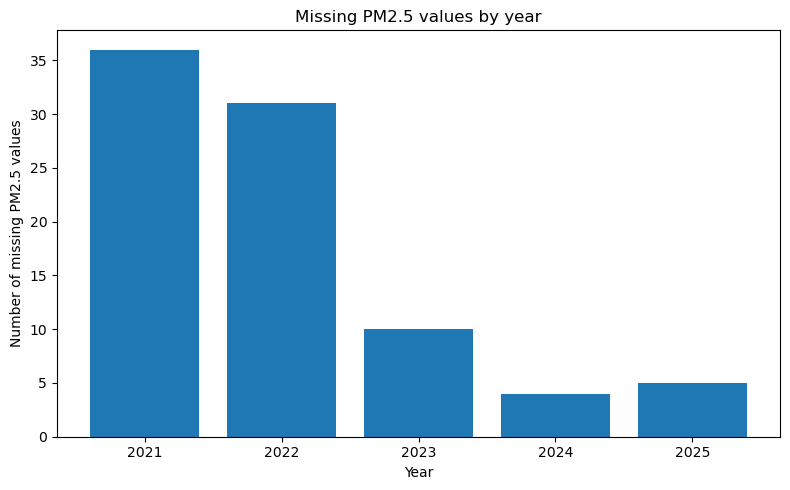

Saved: /Users/hirunikeshika/AIR/outputs/figures/missing_pm25_values_by_year.png


In [40]:
# =========================================================
# 4. Missing PM2.5 values by year
# =========================================================

missing_by_year = (
    df.groupby("year")["pm25_missing_flag"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(missing_by_year["year"].astype(str), missing_by_year["pm25_missing_flag"])
plt.title("Missing PM2.5 values by year")
plt.xlabel("Year")
plt.ylabel("Number of missing PM2.5 values")
plt.tight_layout()

missing_year_path = FIGURE_DIR / "missing_pm25_values_by_year.png"
plt.savefig(missing_year_path, dpi=300)
plt.show()

print("Saved:", missing_year_path)

## 10. Final feature summary and save outputs

## Output files

The final engineered dataset is saved to the GitHub project folder under `data/features/`. This output can be used by the modelling team for PM2.5 forecasting.

The final dataset includes raw PM2.5 values, missing-value flags, time-based attributes, lag features, rolling trend features, rate-of-change features, seasonal cyclical features, and peer-station availability indicators.

In [43]:
# =========================================================
# Final feature summary and save outputs
# =========================================================

feature_cols = [
    col for col in df.columns
    if col.startswith("pm25_lag_")
    or col.startswith("pm25_roll_")
    or col.startswith("pm25_diff_")
    or col.startswith("pm25_rate_change_")
    or col.startswith("peer_pm25_")
    or col in [
        "month_sin",
        "month_cos",
        "day_of_year_sin",
        "day_of_year_cos",
        "pm25_missing_flag"
    ]
]

print("Number of engineered features:", len(feature_cols))
print("\nFeature columns:")
for col in feature_cols:
    print("-", col)

feature_output_path = FEATURE_OUTPUT_DIR / "pm25_complete_engineered_features.csv"
peer_selection_output_path = FEATURE_OUTPUT_DIR / "pm25_dtw_peer_station_selection.csv"

df.to_csv(feature_output_path, index=False)

if len(peer_station_df) > 0:
    peer_station_df.to_csv(peer_selection_output_path, index=False)

print("\nSaved complete feature dataset to:")
print(feature_output_path)

if len(peer_station_df) > 0:
    print("\nSaved peer-station DTW selection to:")
    print(peer_selection_output_path)

print("\nFinal dataset shape:", df.shape)

df.head(10)

Number of engineered features: 55

Feature columns:
- pm25_missing_flag
- pm25_lag_1d
- pm25_lag_2d
- pm25_lag_3d
- pm25_lag_6d
- pm25_lag_7d
- pm25_lag_12d
- pm25_lag_14d
- pm25_lag_30d
- pm25_roll_mean_3d
- pm25_roll_std_3d
- pm25_roll_min_3d
- pm25_roll_max_3d
- pm25_roll_range_3d
- pm25_roll_mean_6d
- pm25_roll_std_6d
- pm25_roll_min_6d
- pm25_roll_max_6d
- pm25_roll_range_6d
- pm25_roll_mean_7d
- pm25_roll_std_7d
- pm25_roll_min_7d
- pm25_roll_max_7d
- pm25_roll_range_7d
- pm25_roll_mean_12d
- pm25_roll_std_12d
- pm25_roll_min_12d
- pm25_roll_max_12d
- pm25_roll_range_12d
- pm25_roll_mean_14d
- pm25_roll_std_14d
- pm25_roll_min_14d
- pm25_roll_max_14d
- pm25_roll_range_14d
- pm25_roll_mean_30d
- pm25_roll_std_30d
- pm25_roll_min_30d
- pm25_roll_max_30d
- pm25_roll_range_30d
- pm25_diff_1d
- pm25_rate_change_1d
- pm25_diff_3d
- pm25_rate_change_3d
- pm25_diff_6d
- pm25_rate_change_6d
- pm25_diff_7d
- pm25_rate_change_7d
- pm25_diff_12d
- pm25_rate_change_12d
- pm25_diff_14d
- pm25_

,date,station,date_raw,pm25_raw,status_raw,source_file,pm25_missing_flag,year,month,day,...,pm25_diff_12d,pm25_rate_change_12d,pm25_diff_14d,pm25_rate_change_14d,month_sin,month_cos,day_of_year_sin,day_of_year_cos,peer_feature_available,peer_feature_note
0,2021-01-01,London Marylebone Road,2021-01-01,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,1,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.017202,0.999852,False,Not available: single-station dataset.
1,2021-01-02,London Marylebone Road,2021-01-02,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,2,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.034398,0.999408,False,Not available: single-station dataset.
2,2021-01-03,London Marylebone Road,2021-01-03,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,3,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.051584,0.998669,False,Not available: single-station dataset.
3,2021-01-04,London Marylebone Road,2021-01-04,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,4,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.068755,0.997634,False,Not available: single-station dataset.
4,2021-01-05,London Marylebone Road,2021-01-05,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,5,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.085906,0.996303,False,Not available: single-station dataset.
5,2021-01-06,London Marylebone Road,2021-01-06,4.542,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,6,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.103031,0.994678,False,Not available: single-station dataset.
6,2021-01-07,London Marylebone Road,2021-01-07,15.333,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,7,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.120126,0.992759,False,Not available: single-station dataset.
7,2021-01-08,London Marylebone Road,2021-01-08,19.958,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,8,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.137185,0.990545,False,Not available: single-station dataset.
8,2021-01-09,London Marylebone Road,2021-01-09,15.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,9,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.154204,0.988039,False,Not available: single-station dataset.
9,2021-01-10,London Marylebone Road,2021-01-10,16.583,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityData_2021-2025.csv,0,2021,1,10,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.171177,0.985240,False,Not available: single-station dataset.
